In [1]:
from datetime import datetime, timedelta
import csv
import sqlite3
import requests
from bs4 import BeautifulSoup
import json
from typing import Dict, List
import re

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import nbformat
import plotly.graph_objects as go

In [3]:
import geopandas as gpd
from shapely.geometry import Point

In [4]:
class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path

    def load_csv(self):
        import pandas as pd
        df = pd.read_csv(self.file_path)
        return df

    def load_multiple_files(self, file_list):
        import pandas as pd
        dfs = [pd.read_csv(f) for f in file_list]
        return pd.concat(dfs, ignore_index=True)

In [36]:
#instance of the class
files = ["Delay_2018_2019.csv", "Delay_2020_2021.csv", "Delay_2022_2023.csv", "Delay_2024.csv"]

loader = DataLoader(None)  # file_path not needed here
df = loader.load_multiple_files(files)

print(df.head())

   year  month carrier       carrier_name airport  \
0  2019     12      9E  Endeavor Air Inc.     ABE   
1  2019     12      9E  Endeavor Air Inc.     AEX   
2  2019     12      9E  Endeavor Air Inc.     AGS   
3  2019     12      9E  Endeavor Air Inc.     ALB   
4  2019     12      9E  Endeavor Air Inc.     ATL   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         53.0        6.0   
1           Alexandria, LA: Alexandria International        115.0        4.0   
2        Augusta, GA: Augusta Regional at Bush Field        191.0       13.0   
3                   Albany, NY: Albany International          6.0        1.0   
4  Atlanta, GA: Hartsfield-Jackson Atlanta Intern...       3804.0      470.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        3.05        0.22  ...         0.00              2.52            0.0   
1        0.03        0.00  ...         0

In [62]:
class DataCleaner:
    def clean(self, df):
        df = df.copy()

        # handle missing values
        #df.dropna(inplace=True)
        df = df.dropna(subset=['arr_delay'])

        #create features
        df['is_delayed'] = df['arr_delay'] > 15
        df['delay_minutes'] = df['arr_delay'].clip(lower=0)

        # extract time features
        #df['hour'] = df['CRSDepTime'] // 100
        #df['month'] = df['month']

        return df

In [49]:
#Call the clean method - for dropna method
cleaner = DataCleaner()
cleaned_df = cleaner.clean(df)

In [50]:
#Which airline is most reliable
df.groupby('carrier_name')['arr_delay'].mean()

carrier_name
Air Wisconsin Airlines Corp                 1679.034400
Alaska Airlines Network                     2176.182746
Allegiant Air                               1329.657123
American Airlines Network                  10062.327275
Delta Air Lines Network                     5317.807608
Endeavor Air Inc.                           1985.083699
Envoy Air                                   1755.855429
ExpressJet Airlines Inc.                    2434.043062
ExpressJet Airlines LLC                     1739.189114
Frontier Airlines                           2684.308203
GoJet Airlines LLC d/b/a United Express     1474.921477
Hawaiian Airlines Network                   2090.110625
Horizon Air                                 1236.126683
JetBlue Airways                             6558.421390
Mesa Airlines Inc.                          2139.596255
Piedmont Airlines                           1518.560811
Republic Airline                            3074.907714
SkyWest Airlines Inc.              

In [40]:
#What month has the highest delays
df.groupby('month')['arr_delay'].mean().sort_values()

month
11    2882.148124
9     2960.028161
10    3044.554493
2     3363.852386
4     3466.217115
3     3521.261677
1     3702.398919
5     4017.067279
12    4070.993399
8     4846.188778
6     5076.556148
7     5725.330638
Name: arr_delay, dtype: float64

In [64]:
df['state'] = df['airport_name'].str.extract(r',\s*([A-Z]{2}):')

In [65]:
df['state'] = df['state'].str.upper()

In [66]:
df['state'] = 'US-' + df['state']

In [67]:
df['state']

0         US-PA
1         US-LA
2         US-GA
3         US-NY
4         US-GA
          ...  
148857    US-NC
148858    US-VA
148859    US-NV
148860    US-NY
148861    US-FL
Name: state, Length: 148383, dtype: object

In [28]:
#Which airports are bottlenecks
bneck = df.groupby(['year','airport_name'])['arr_delay'].mean()

In [29]:
bneck = bneck.reset_index()

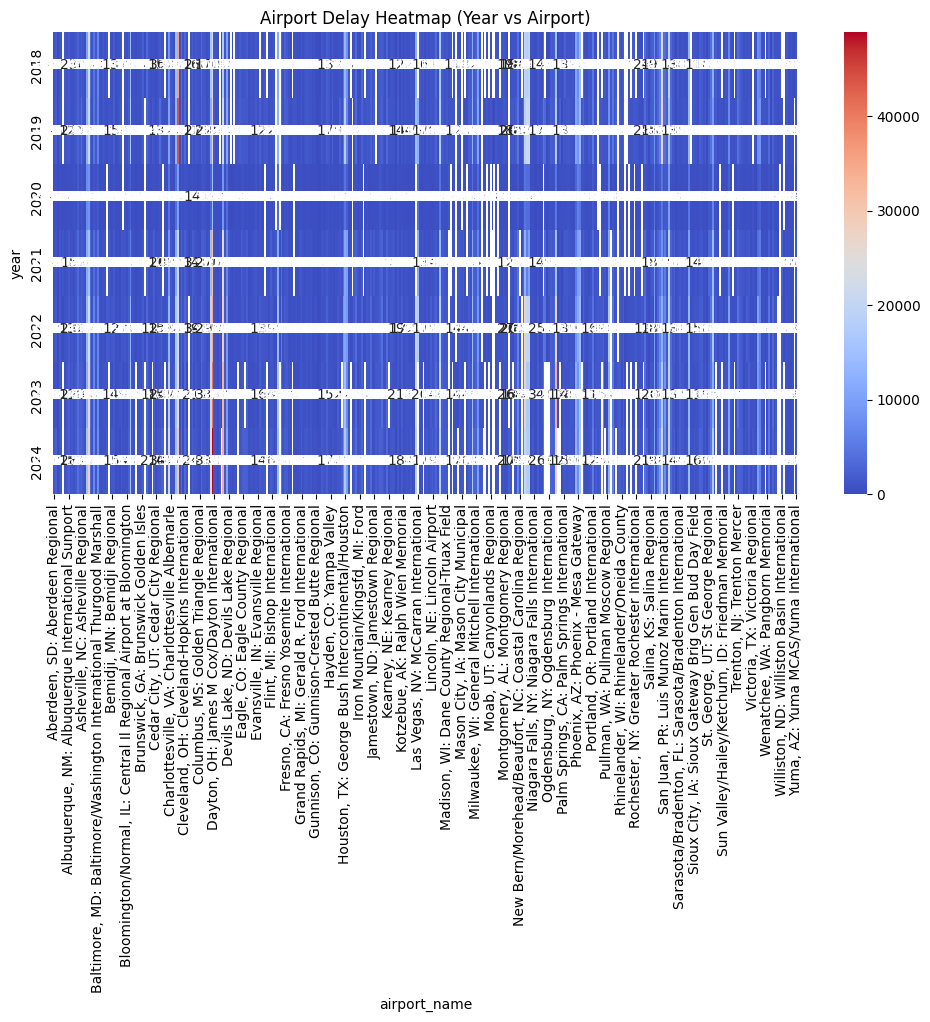

In [89]:
pivot = bneck.pivot(index='year', columns='airport_name', values='arr_delay')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")

plt.title("Airport Delay Heatmap (Year vs Airport)")
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

for airport in bneck['airport_name'].unique():
    subset = bneck[bneck['airport_name'] == airport]
    plt.plot(subset['year'], subset['arr_delay'], marker='o', label=airport)

plt.title("Average Arrival Delay by Airport Over Time")
plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
#Delay & cancellation patterns
df.groupby(['year','carrier_name'])['arr_cancelled'].mean()

year  carrier_name               
2018  Air Wisconsin Airlines Corp     3.803140
      Alaska Airlines Network         2.608747
      Allegiant Air                   0.547331
      American Airlines Network      12.729983
      Delta Air Lines Network         2.007399
                                       ...    
2024  Republic Airline                5.869198
      SkyWest Airlines Inc.           2.992212
      Southwest Airlines              9.254717
      Spirit Airlines                 6.970711
      United Air Lines Network        9.009386
Name: arr_cancelled, Length: 137, dtype: float64

In [38]:
#Delay & cancellation patterns 2
result = (
    df.groupby(['year', 'carrier_name'])['arr_cancelled']
    .mean()
    .reset_index()
    .sort_values(['year', 'arr_cancelled'])
)

In [40]:
#Pivot table
pivot = df.pivot_table(
    index='year',
    columns='carrier_name',
    values='arr_cancelled',
    aggfunc='mean'
)
pivot

carrier_name,Air Wisconsin Airlines Corp,Alaska Airlines Network,Allegiant Air,American Airlines Network,Delta Air Lines Network,Endeavor Air Inc.,Envoy Air,ExpressJet Airlines Inc.,ExpressJet Airlines LLC,Frontier Airlines,...,Hawaiian Airlines Network,Horizon Air,JetBlue Airways,Mesa Airlines Inc.,Piedmont Airlines,Republic Airline,SkyWest Airlines Inc.,Southwest Airlines,Spirit Airlines,United Air Lines Network
year,,,,,,,,,,,,,,,,,,,,,
2018,3.803140,2.608747,0.547331,12.729983,2.007399,4.899767,6.740506,3.936858,NaN,2.487701,...,1.087629,3.010121,8.023750,4.376371,9.282544,9.824390,3.813793,17.811891,3.574074,4.015561
2019,4.084691,3.558382,0.436059,16.043790,1.064740,3.486420,6.677400,5.200000,4.750588,1.933051,...,0.608889,4.952191,4.801020,4.948987,6.384720,6.893178,5.865112,32.082061,6.221837,4.262866
2020,5.926174,6.758323,9.859310,29.561691,20.403546,5.610348,6.678998,NaN,6.898799,4.233755,...,13.484277,8.403846,11.877976,7.019366,8.779904,11.034627,9.087290,72.478585,5.058020,23.243827
2021,3.157274,3.574444,2.550966,13.484452,2.571530,0.716703,3.346675,NaN,NaN,1.627848,...,1.060241,3.552542,4.525377,4.053617,1.783019,5.272642,4.848253,19.187755,9.204878,5.264655
2022,3.102273,6.377436,2.725464,19.095870,8.810462,6.852843,3.243917,NaN,NaN,4.061076,...,2.605364,2.666667,13.067775,3.267016,2.697568,15.948387,4.637895,33.220405,10.284661,9.080214
2023,1.261076,1.910145,0.533788,6.714670,5.850467,3.602553,1.420337,NaN,NaN,4.053706,...,4.178571,0.929791,7.341401,2.035714,0.952712,8.508863,2.861237,11.156542,5.973369,7.681376
2024,1.305983,4.643822,1.402363,10.305405,5.345996,3.893311,2.276860,NaN,NaN,5.149095,...,3.161538,1.407470,4.920949,2.397226,1.049383,5.869198,2.992212,9.254717,6.970711,9.009386


<Axes: xlabel='year'>

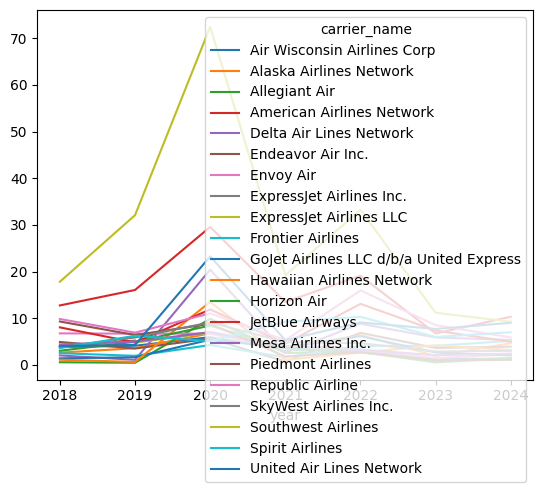

In [41]:
pivot.plot()

In [43]:
#What factors most influence delays
#df.groupby('month')['arr_delay'].mean().sort_values()

delay_factors = df[[
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]].sum()

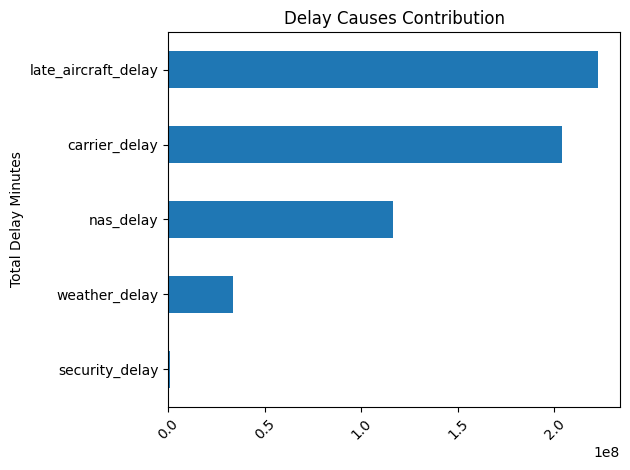

In [46]:
delay_factors.sort_values().plot(kind='barh')

plt.title("Delay Causes Contribution")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
delay_pct = delay_factors / delay_factors.sum() * 100

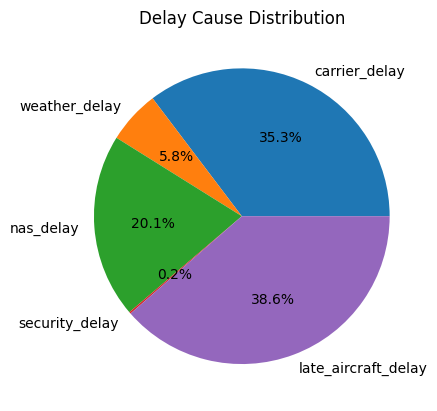

In [49]:
delay_pct.plot(kind='pie', autopct='%1.1f%%')

plt.title("Delay Cause Distribution")
plt.ylabel("")
plt.show()

In [63]:
airline_factor = df.groupby('carrier_name')[[
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]].mean().nlargest(10, 'carrier_delay')

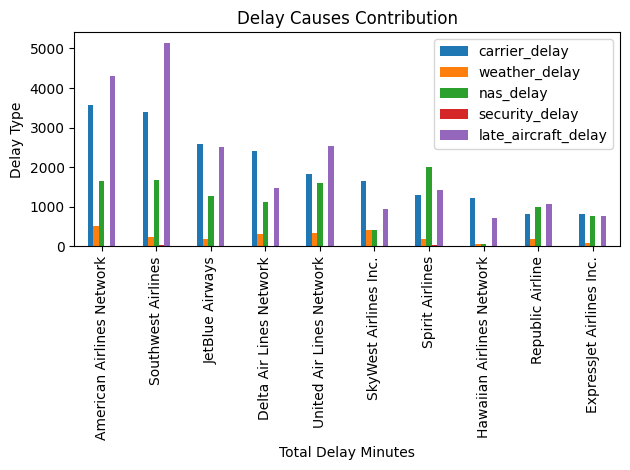

In [64]:
#airline_factor.sort_values().plot(kind='barh')
airline_factor.plot(kind='bar')

plt.title("Delay Causes Contribution")
plt.xlabel("Total Delay Minutes")   # ← use xlabel for barh
plt.ylabel("Delay Type")
plt.tight_layout()
plt.show()

In [71]:
df_filtered = df[df['year'].isin([2019, 2020, 2021, 2022, 2023])]

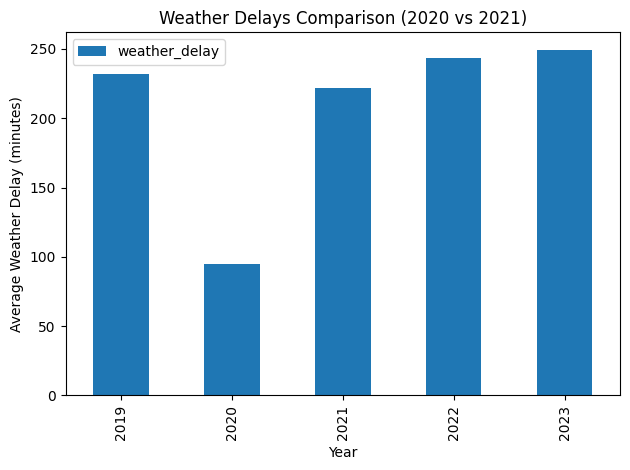

In [73]:
#Waether factor only
#weather_factor = df_filtered.groupby(['year','carrier_name'])[['weather_delay']].mean()
weather_factor = df_filtered.groupby('year')[['weather_delay']].mean()

weather_factor.plot(kind='bar')
plt.title("Weather Delays Comparison (2020 vs 2021)")
plt.xlabel("Year")
plt.ylabel("Average Weather Delay (minutes)")
plt.tight_layout()
plt.show()

In [74]:
#Delay and cancellation patterns across airlines

airline_patterns = df.groupby('carrier_name').agg(
    avg_delay=('arr_delay', 'mean'),
    cancellation_rate=('arr_cancelled', 'mean'),
    total_flights=('carrier_name', 'count')
)

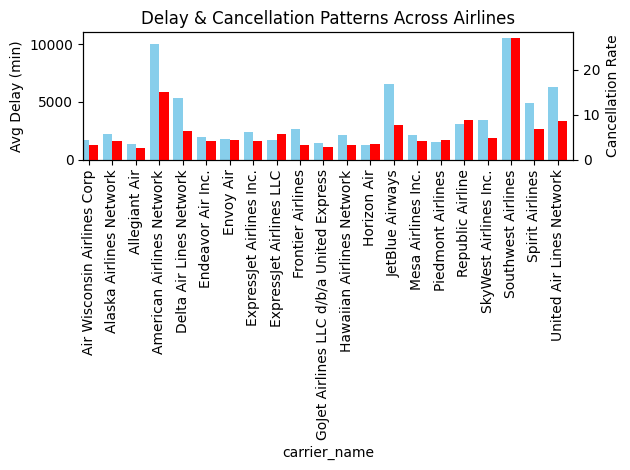

In [83]:

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

airline_patterns['avg_delay'].plot(kind='bar', ax=ax1, color='skyblue', position=1, width=0.4)
airline_patterns['cancellation_rate'].plot(kind='bar', ax=ax2, color='red', position=0, width=0.4)

ax1.set_ylabel("Avg Delay (min)")
ax2.set_ylabel("Cancellation Rate")

plt.title("Delay & Cancellation Patterns Across Airlines")
plt.tight_layout()
plt.show()

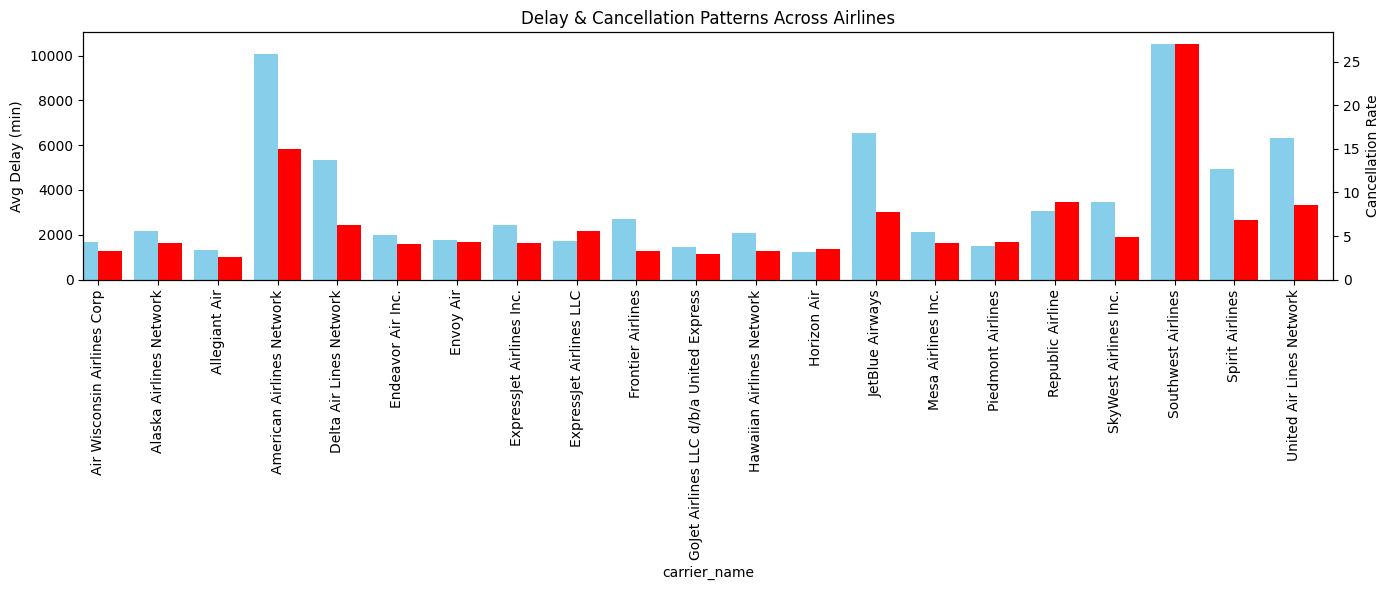

In [84]:

fig, ax1 = plt.subplots(figsize=(14, 6))  # 👈 width, height

ax2 = ax1.twinx()

airline_patterns['avg_delay'].plot(
    kind='bar',
    ax=ax1,
    color='skyblue',
    position=1,
    width=0.4
)

airline_patterns['cancellation_rate'].plot(
    kind='bar',
    ax=ax2,
    color='red',
    position=0,
    width=0.4
)

ax1.set_ylabel("Avg Delay (min)")
ax2.set_ylabel("Cancellation Rate")

plt.title("Delay & Cancellation Patterns Across Airlines")
plt.tight_layout()
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148862 entries, 0 to 148861
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 148862 non-null  int64  
 1   month                148862 non-null  int64  
 2   carrier              148862 non-null  object 
 3   carrier_name         148862 non-null  object 
 4   airport              148862 non-null  object 
 5   airport_name         148862 non-null  object 
 6   arr_flights          148597 non-null  float64
 7   arr_del15            148383 non-null  float64
 8   carrier_ct           148597 non-null  float64
 9   weather_ct           148597 non-null  float64
 10  nas_ct               148597 non-null  float64
 11  security_ct          148597 non-null  float64
 12  late_aircraft_ct     148597 non-null  float64
 13  arr_cancelled        148597 non-null  float64
 14  arr_diverted         148597 non-null  float64
 15  arr_delay        

In [93]:
class DatabaseManager:
    def __init__(self, db_name = "Airline_delay.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()

    #def save_table(self, df, table_name):
    #    df.to_sql(table_name, self.conn, if_exists='replace', index=False)

    def query(self, sql_query):
        return pd.read_sql(sql_query, self.conn)
    
    def add_column(self, table_name, column_name, data_type):
        self.cursor.execute(f"""
        ALTER TABLE {table_name}
        ADD COLUMN {column_name} {data_type};
        """)
        self.conn.commit()
    
    def execute2(self, sql_query):
        self.cursor.execute(sql_query)
        self.conn.commit()

    def execute(self, sql_query, params=None):
        if params:
            self.cursor.execute(sql_query, params)
        else:
            self.cursor.execute(sql_query)
        self.conn.commit()

    def close(self):
        self.conn.close()

In [5]:
db = DatabaseManager()

In [20]:
result = db.query("SELECT * FROM delays LIMIT 5")
print(result)

   year  month carrier       carrier_name airport  \
0  2019     12      9E  Endeavor Air Inc.     ABE   
1  2019     12      9E  Endeavor Air Inc.     AEX   
2  2019     12      9E  Endeavor Air Inc.     AGS   
3  2019     12      9E  Endeavor Air Inc.     ALB   
4  2019     12      9E  Endeavor Air Inc.     ATL   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         53.0        6.0   
1           Alexandria, LA: Alexandria International        115.0        4.0   
2        Augusta, GA: Augusta Regional at Bush Field        191.0       13.0   
3                   Albany, NY: Albany International          6.0        1.0   
4  Atlanta, GA: Hartsfield-Jackson Atlanta Intern...       3804.0      470.0   

   carrier_ct  weather_ct  ...  late_aircraft_ct  arr_cancelled  arr_diverted  \
0        3.05        0.22  ...              2.52            0.0           0.0   
1        0.03        0.00  ...        

In [19]:
#alter table - add new column named State_abbr
db = DatabaseManager()
db.add_column("delays", "state", "TEXT")

In [ ]:
db = DatabaseManager()

result = db.query("""
SELECT * FROM delays WHERE 1=0
""")

print(result.head())

Empty DataFrame
Columns: [year, month, carrier, carrier_name, airport, airport_name, arr_flights, arr_del15, carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct, arr_cancelled, arr_diverted, arr_delay, carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay, state]
Index: []

[0 rows x 22 columns]


In [80]:
result = db.query(""
"SELECT airport_name FROM delays"
"")
state = result

In [87]:
len(state)

148801

In [82]:
print(state.head())

                                        airport_name
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...
1           Alexandria, LA: Alexandria International
2        Augusta, GA: Augusta Regional at Bush Field
3                   Albany, NY: Albany International
4  Atlanta, GA: Hartsfield-Jackson Atlanta Intern...


In [83]:
state['state'] = state['airport_name'].str.extract(r',\s*([A-Z]{2}):', expand=False)

In [86]:
state['state'].head()

0    US-PA
1    US-LA
2    US-GA
3    US-NY
4    US-GA
Name: state, dtype: object

In [85]:
state['state']= 'US-' + state['state']

In [94]:
# add content of State['state] to the Table
db = DatabaseManager()

for i, val in enumerate(state['state']):
    db.execute("""
        UPDATE delays
        SET state = ?
        WHERE rowid = ?
    """, (val, i + 1))

#conn.commit()

In [95]:
db = DatabaseManager()

result = db.query("""
SELECT count(*) FROM delays
""")

print(result)

   count(*)
0    148801


In [97]:
result = db.query("SELECT COUNT(state) FROM delays LIMIT 5")
print(result)

   COUNT(state)
0        148801


In [11]:
db = DatabaseManager()

result = db.query("""
SELECT month, AVG(arr_delay) AS avg_delay
FROM delays
WHERE year = 2021
GROUP BY month
ORDER BY month
""")

print(result)

    month    avg_delay
0       1  1393.732968
1       2  1917.666875
2       3  1629.289742
3       4  1836.963429
4       5  2465.359257
5       6  4985.643172
6       7  5829.352709
7       8  5001.215359
8       9  2616.229338
9      10  3562.358119
10     11  2679.790556
11     12  4356.448876


In [12]:
class Analyzer:
    def __init__(self, df):
        self.df = df

    def airline_reliability(self):
        return (
            self.df.groupby('carrier_name')
            .agg(avg_delay=('arr_delay', 'mean'),
                 delay_rate=('is_delayed', 'mean'),
                 total_flights=('carrier', 'count'))
            .sort_values(by='delay_rate')
        )
    
    def delays_by_hour(self):
        return (
            self.df.groupby('hour')['arr_delay']
            .mean()
            .sort_index()
        )

    def airport_bottlenecks(self):
        return (
            self.df.groupby('airport')
            .agg(avg_delay=('arr_delay', 'mean'),
                 traffic=('airport', 'count'))
            .sort_values(by='avg_delay', ascending=False)
        )

In [13]:
# cleaned df
analyzer = Analyzer(cleaned_df)

In [14]:
result = analyzer.airline_reliability()
print(result)

                                            avg_delay  delay_rate  \
carrier_name                                                        
ExpressJet Airlines LLC                   1739.189114    0.851361   
GoJet Airlines LLC d/b/a United Express   1474.921477    0.874049   
Air Wisconsin Airlines Corp               1679.034400    0.896600   
Republic Airline                          3074.907714    0.910143   
Piedmont Airlines                         1518.560811    0.913595   
Mesa Airlines Inc.                        2139.596255    0.917627   
Frontier Airlines                         2684.308203    0.924746   
Allegiant Air                             1329.657123    0.927640   
ExpressJet Airlines Inc.                  2434.043062    0.928828   
Endeavor Air Inc.                         1985.083699    0.930289   
Envoy Air                                 1755.855429    0.942085   
Horizon Air                               1236.126683    0.943785   
United Air Lines Network          

In [15]:
class Visualizer:
    def plot_airline_performance(self, df):
        
        df['delay_rate'].plot(kind='bar')
        plt.title("Airline Delay Rate")
        plt.ylabel("Delay Rate")
        plt.show()

    def plot_delay_trends(self, df):
        
        df.plot()
        plt.title("Delays by Hour")
        plt.xlabel("Hour")
        plt.ylabel("Average Delay")
        plt.show()

In [16]:
viz = Visualizer()

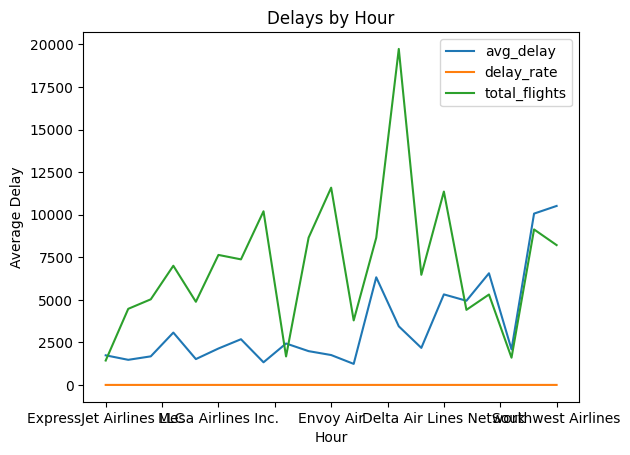

In [18]:
viz.plot_delay_trends(result)

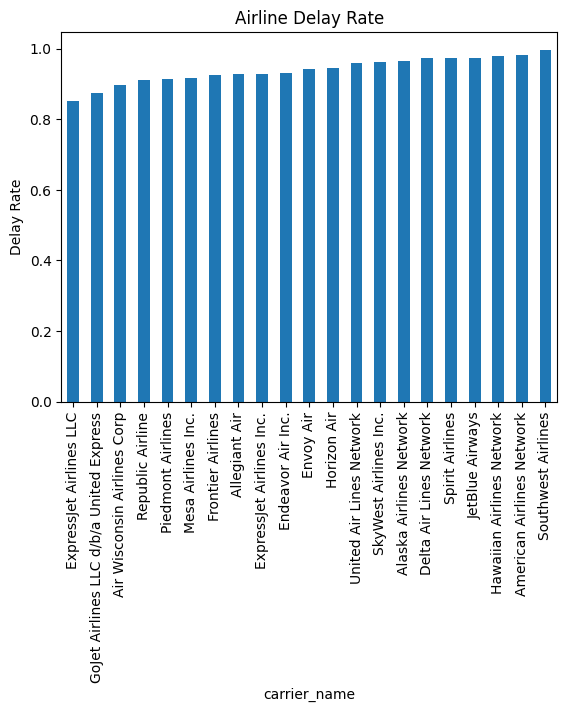

In [17]:
viz.plot_airline_performance(result)